# SOLUTIONS AND EXPLANATIONS FOR LESSON 1: MATRIX FOR AI (20/6/2026) HOMEWORK - USING TEXTS

## PREPARATION FOR BOTH EXERCISES: TRANSFORM TEXTS TO VECTORS AND MATRIXES

Import numpy lib and create a list of 8 sentences to transform to vectors

In [28]:
import numpy as np
sentence = ["i love you", 
            "this house is big",
            "you are beautiful",
            "that will do",
            "you are welcome", 
            "how are you", 
            "what is your name", 
            "i play badminton"]

extract each separate word from every sentence and then sort them in alphabet order

In [29]:
word = []
for s in sentence:
    for w in s.lower().split():
        word.append(w)
word.sort()
print(word)

['are', 'are', 'are', 'badminton', 'beautiful', 'big', 'do', 'house', 'how', 'i', 'i', 'is', 'is', 'love', 'name', 'play', 'that', 'this', 'welcome', 'what', 'will', 'you', 'you', 'you', 'you', 'your']


This method uses list, but some words can be duplicated so we must change to set, then sorted() will give us back a list that can be extracted using index.

In [30]:
vocab = sorted({w for s in sentence for w in s.lower().split()})
print(vocab)
print(len(vocab))

['are', 'badminton', 'beautiful', 'big', 'do', 'house', 'how', 'i', 'is', 'love', 'name', 'play', 'that', 'this', 'welcome', 'what', 'will', 'you', 'your']
19


building a function to transform these words to vectors

In [31]:
def to_vectors(s):
    v = np.zeros(len(vocab)) # an array all 0 with length of word list above
    for w in s.lower().split():
        if w in vocab: # make sure when search a new word it does not error finding it in the list.
            v[vocab.index(w)] += 1 
    return v
matrix = np.array([to_vectors(s) for s in sentence], dtype=int)
print(matrix)
print(matrix.shape)

[[0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0]
 [0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0]
 [1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 1]
 [0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0]]
(8, 19)


Here, 8 sentences are separately transformed to 8 vectors (each with 19 dims or 19 words in total) which makes a 8x19 matrix.
- 8 rows are 8 sentences whose "1" stands at the index corresponds to a word in the sorted word list above
- Each column represents the frequency that each word appears in each sentence. for ex, the first column represents for word[0] ('are') that 'are' appears in sentence 3,5 and 6 one time.

## EXERCISE 1: CALCULATE THE SIMILARITY

### Basic operation: Mean-centering

We take the mean of each column

In [32]:
col_mean = np.mean(matrix, axis=0, keepdims=True) # axis=0 means that we are taking average by columns (=1 is for rows)
print(col_mean)
print(col_mean.shape)

[[0.375 0.125 0.125 0.125 0.125 0.125 0.125 0.25  0.25  0.125 0.125 0.125
  0.125 0.125 0.125 0.125 0.125 0.5   0.125]]
(1, 19)


first column average = 3/8 = 0.375. Here we keep the original dims with 19 columns

Now, mean centering

In [33]:
centered_matrix = matrix - col_mean
print(centered_matrix)
print(centered_matrix.shape)

[[-0.375 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125  0.75  -0.25   0.875
  -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125  0.5   -0.125]
 [-0.375 -0.125 -0.125  0.875 -0.125  0.875 -0.125 -0.25   0.75  -0.125
  -0.125 -0.125 -0.125  0.875 -0.125 -0.125 -0.125 -0.5   -0.125]
 [ 0.625 -0.125  0.875 -0.125 -0.125 -0.125 -0.125 -0.25  -0.25  -0.125
  -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125  0.5   -0.125]
 [-0.375 -0.125 -0.125 -0.125  0.875 -0.125 -0.125 -0.25  -0.25  -0.125
  -0.125 -0.125  0.875 -0.125 -0.125 -0.125  0.875 -0.5   -0.125]
 [ 0.625 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.25  -0.25  -0.125
  -0.125 -0.125 -0.125 -0.125  0.875 -0.125 -0.125  0.5   -0.125]
 [ 0.625 -0.125 -0.125 -0.125 -0.125 -0.125  0.875 -0.25  -0.25  -0.125
  -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125  0.5   -0.125]
 [-0.375 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.25   0.75  -0.125
   0.875 -0.125 -0.125 -0.125 -0.125  0.875 -0.125 -0.5    0.875]
 [-0.375  0.875 -0.125 -0.125 -0.1

Numpy will automatically copy the col_mean matrix above to 7 more rows to make a 8x19 matrix (same shape as matrix). This is called broadcasting in Numpy.  
Subtracting each entry with the average will make each column's mean = 0.

In [34]:
column_mean = np.mean(centered_matrix, axis=0, keepdims=True)
print(column_mean)

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


### Cosine similarity

is basically comparing the value of cosine between 2 vectors:
- ~1 means they are highly related

In [35]:
def cosine_similarity(X, Y = None):
    if Y is None:
        Y = X
    
    X_norm = np.linalg.norm(X, axis=1, keepdims=True)
    Y_norm = np.linalg.norm(Y, axis=1, keepdims=True)

    X_norm[X_norm == 0] = 1 # to make sure when search a new word, python would not throw a 0 divided error
    Y_norm[Y_norm == 0] = 1

    Xn = X / X_norm
    Yn = Y / Y_norm

    return Xn @ Yn.T

This function corresponds to the formula: $cos = \frac{u \times v}{||u|| \times ||v||}$

In [36]:
# Calculate with sentence 1 and 2
print(f'cosine similarity of sentence 1 and 2 is: {cosine_similarity(matrix[0:1], matrix[1:2])}')

# Calculate with sentence 1 and 8
print(f'cosine similarity of sentence 1 and 8 is: {cosine_similarity(matrix[0:1], matrix[7:8])}')

# Calculate with sentence 3 and 5
print(f'cosine similarity of sentence 3 and 5 is: {cosine_similarity(matrix[2:3], matrix[4:5])}')


cosine similarity of sentence 1 and 2 is: [[0.]]
cosine similarity of sentence 1 and 8 is: [[0.33333333]]
cosine similarity of sentence 3 and 5 is: [[0.66666667]]


sentence 1 and 2 have 0/3 identical words. Cos = 0 means 2 vectors are perpendicular and are not related  
whereas 1 and 8 have 1/3 and 3 and 5 have 2/3

### Word Embedding - Semantic research

The to_vector method above is just a way to vectorize a sentence to count the appearance of words. It does not account for the semantic or meaning of them.  
For example, 'I go by bike' and 'I ride a bicycle' would end up having a very ~0 cosine value as the function doesn't know that bike and bicycle are synonyms or go by and ride is almost the same.


This is where Semantic search is introduced.  
First, engineers create a vector that has 100-768 dims (most LLMs now choose 768) representing for a separate word. Each dim is a randomly generated number which show a property of that word.  
Then the model will go through 2 games: masked language modelling and next sentence prediction to adjust those numbers so that each word will have its own set and the relations between vocabs are precise. For ex, 'cat' and 'dog' will be closed not 'cat' and 'car'.  
Finally, when users input, the model will use cosine similarity to find the top-related words in terms of context and meaning.

The same goes for sentences. Here we will simulate the algorithm by using our own matrix 8x19 from the beginning.

In [37]:
print(matrix)
print(matrix.shape)

[[0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0]
 [0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0]
 [1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 1]
 [0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0]]
(8, 19)


create a semantic search function

In [38]:
def search(query, top_k=3):
    q_vec = to_vectors(query).reshape(1, len(vocab)) # transform the user input also to a 1x19
    print(q_vec)

    cos = cosine_similarity(q_vec, matrix) # thanks to broadcasting, numpy will calculate the cosine similarity of q to each of our sentence
    cos = cos.flatten() # change to 1D (array) for easier cals
    print(cos)

    #In order to sort from small to big cos value without losing track of which value correspond to which sentence -> use argsort
    cos_idx_sort = np.argsort(cos)
    print(cos_idx_sort)

    T_k = cos_idx_sort[-top_k:][::-1] # Take out top 3 and then sort backwards to get big -> small
    print(T_k)

    return [(sentence[x], round(float(cos[x]), 3)) for x in T_k]

search('love you')

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]
[0.81649658 0.         0.40824829 0.         0.40824829 0.40824829
 0.         0.        ]
[1 3 6 7 5 2 4 0]
[0 4 2]


[('i love you', 0.816),
 ('you are welcome', 0.408),
 ('you are beautiful', 0.408)]

The pair ~1 is most related.  
The results are almost the same as we thought as we use the matrix from the beginning not a random one.

In [39]:
search('skibidi toilet')

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
[0. 0. 0. 0. 0. 0. 0. 0.]
[0 1 2 3 4 5 6 7]
[7 6 5]


[('i play badminton', 0.0), ('what is your name', 0.0), ('how are you', 0.0)]

When we search a word or a sentence that contains some words that are not in the list (like "skibidi"), python would throw 2 errors:
- not in the list -> v[vocab.index(w)] cannot find the index of skibidi.
- cannot divide by 0 when calculate cosine similarity    
So we have to modify to_vector() and cosine_similarity()

## EXERCISE 2: LINEAR TRANSFORMATION & SVD

SVD is a way to decompose a matrix into 3 components that can show the variance of data (referencing our major assignment in Linear Algebra - Randomized PCA).  
centered_matrix = $U \Sigma V^\top$

In [40]:
U, Sigma, Vt = np.linalg.svd(centered_matrix, full_matrices=False)
print(U.shape)
print(Sigma.shape)
print(Vt.shape)

(8, 8)
(8,)
(8, 19)


Then we truncate each components down to 2 dims

In [41]:
U_k = U[:,:2]
print(U_k)
print(U_k.shape)

Sigma_k = Sigma[:2]
print(Sigma_k)
print(Sigma_k.shape)

[[ 0.16130518  0.32732684]
 [-0.50148896 -0.32732684]
 [ 0.37743107 -0.21821789]
 [-0.17181994  0.32732684]
 [ 0.37743107 -0.21821789]
 [ 0.37743107 -0.21821789]
 [-0.50148896 -0.32732684]
 [-0.11880051  0.65465367]]
(8, 2)
[2.45812499 2.        ]
(2,)


Here, we don't use Vt because if multiply, it will become the original with separate words.  
We just want to embed 8 sentences + 8 topics and their weights.

In [42]:
Sigma_k = np.diag(Sigma_k) # transform Sigma_k from 1D array to square matrix
sentence_embed = U_k @ Sigma_k
print(sentence_embed)

[[ 0.39650828  0.65465367]
 [-1.23272255 -0.65465367]
 [ 0.92777274 -0.43643578]
 [-0.42235489  0.65465367]
 [ 0.92777274 -0.43643578]
 [ 0.92777274 -0.43643578]
 [-1.23272255 -0.65465367]
 [-0.29202651  1.30930734]]


Now, each sentence has been cut down to 2 dims presenting their 2 most significant features/topics.  
We will sketch this to a graph to demonstrate.

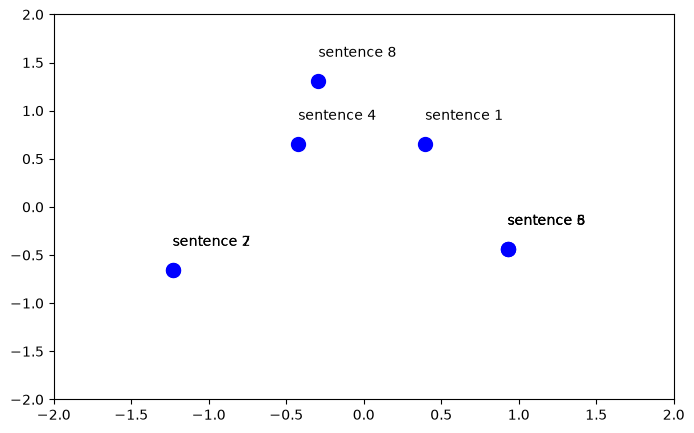

In [43]:
import matplotlib.pyplot as plt

x_coords = sentence_embed[:, 0] # first column
y_coords = sentence_embed[:, 1]

plt.figure(figsize = (8, 5))
plt.scatter(x_coords, y_coords, s=100, c='blue')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
for i in range(len(sentence)):
    plt.text(x_coords[i], y_coords[i] + 0.25, f"sentence {i + 1}")


As we can see sentence 1, 4 and 8 are separated as they are not really related in words.  
However, 2 and 7 both have the word "is" so they are grouped together. Here they are overlapped mainly because we have truncated many other properties of the them so coincidentally, they end up sharing the same word with the highest weight.  
The same goes for sentence 3, 5, 6 as they all have "you" and "are"

Now we will come to PCA (Principal Component Analysis) by adding Vt to the graph.  
Vt is a 19x19 matrix that contains 19 principle components or 19 axis/directions that data varies the most + 19 properties (words).  
We now truncate it down to 2 PCs and then sketch it on the graph to see.

[[ 0.46063288 -0.04832973  0.15354429 -0.2040128  -0.06989878 -0.2040128
   0.15354429  0.0172915  -0.4080256   0.06562123 -0.2040128  -0.04832973
  -0.06989878 -0.2040128   0.15354429 -0.2040128  -0.06989878  0.52625411
  -0.2040128 ]
 [-0.32732684  0.32732684 -0.10910895 -0.16366342  0.16366342 -0.16366342
  -0.10910895  0.49099025 -0.32732684  0.16366342 -0.16366342  0.32732684
   0.16366342 -0.16366342 -0.10910895 -0.16366342  0.16366342 -0.16366342
  -0.16366342]]


(-2.0, 2.0)

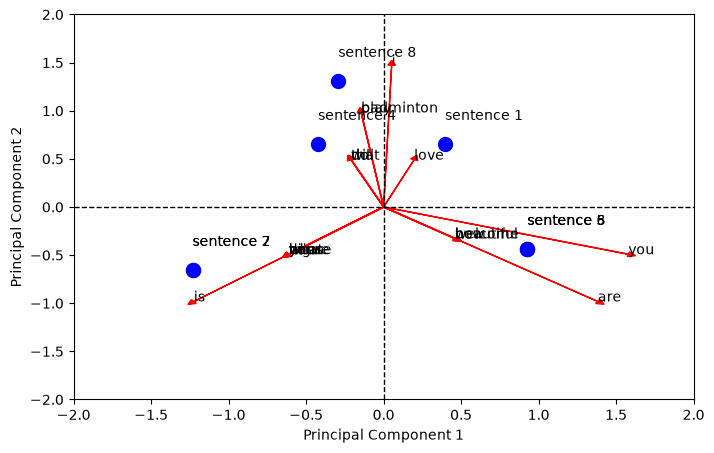

In [44]:
word_embed_coords = Vt[:2, :]
print(word_embed_coords)

plt.figure(figsize = (8, 5))
plt.scatter(x_coords, y_coords, s=100, c='blue')
for i in range(len(sentence)):
    plt.text(x_coords[i], y_coords[i] + 0.25, f"sentence {i + 1}")

for x, word in enumerate(vocab): # enumerate() returns index and item
    plt.arrow(0, 0, word_embed_coords[0, x] * 3, word_embed_coords[1, x] * 3, color='red', head_width=0.05, head_length=0.05) # scale up for better visualization
    plt.text(word_embed_coords[0, x] * 3, word_embed_coords[1, x] * 3, word)

plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.axvline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.xlim(-2, 2)
plt.ylim(-2, 2)


As we can see PC 1 are mostly made by the words "you", "are" and other small contributions like "love", "beautiful",...  
This is precise because PC 1 is where data varies the most and looking back at our 8 sentences, most of them consists of "you" and "are"

## 1-NN CLASSIFICATION

K-Nearest Neighbor is an algorithm just like the semantic search but outputs the labels of data instead of the data itself.  
This is especially beneficial when dealing with enormous amount of training data that would translate to massive matrixes, as the output is much shorter and smaller and easier for models to understand and execute.

Now we will label each sentence with labels in the correct order.

In [45]:
labels = ["romantic", "description", "compliment", "agreement", "politeness", "greeting", "greeting", "hobby"]

Then build a function to predict 1-NN, just like the semantic search

In [46]:
def search_1NN(query):
    q_vec = to_vectors(query).reshape(1, len(vocab))

    if np.sum(q_vec) == 0:
        return "unknown category (no matching words)"

    cos = cosine_similarity(q_vec, matrix).flatten()
    idx = np.argsort(cos)[-1]

    return f"{query} is likely {labels[idx]}, most identical to {sentence[idx]}, cos ~{cos[idx]}"

print(search_1NN("you are my love"))
search_1NN("I love playing games")

you are my love is likely politeness, most identical to you are welcome, cos ~0.6666666666666669


'I love playing games is likely romantic, most identical to i love you, cos ~0.816496580927726'

when the input is "you are my love", both "i love you" and "you are welcome" have 2/3 matching words (cos ~0.6667) but 1-NN choose politeness over romantic.  
This is a typical limitation of 1-NN cuz it only picks the largest cosine similarity value but does not care about if others share the same property. To tackle this, engineers would increase k to 3-NN or 4-NN.